In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

(45593, 20)
(11399, 19)


In [2]:
train.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [4]:
train.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


In [5]:
train.duplicated().sum()

np.int64(0)

In [6]:
for col in train.select_dtypes(include="object").columns:
    print("\n", col)
    print(train[col].unique()[:15])


 ID
['0x4607 ' '0xb379 ' '0x5d6d ' '0x7a6a ' '0x70a2 ' '0x9bb4 ' '0x95b4 '
 '0x9eb2 ' '0x1102 ' '0xcdcd ' '0xd987 ' '0x2784 ' '0xc8b6 ' '0xdb64 '
 '0x3af3 ']

 Delivery_person_ID
['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' 'COIMBRES13DEL02 '
 'CHENRES12DEL01 ' 'HYDRES09DEL03 ' 'RANCHIRES15DEL01 ' 'MYSRES15DEL02 '
 'HYDRES05DEL02 ' 'DEHRES17DEL01 ' 'KOCRES16DEL01 ' 'PUNERES13DEL03 '
 'LUDHRES15DEL02 ' 'KNPRES14DEL02 ' 'MUMRES15DEL03 ']

 Delivery_person_Age
['37' '34' '23' '38' '32' '22' '33' '35' '36' '21' '24' '29' '25' '31'
 '27']

 Delivery_person_Ratings
['4.9' '4.5' '4.4' '4.7' '4.6' '4.8' '4.2' '4.3' '4' '4.1' '5' '3.5'
 'NaN ' '3.8' '3.9']

 Order_Date
['19-03-2022' '25-03-2022' '05-04-2022' '26-03-2022' '11-03-2022'
 '04-03-2022' '14-03-2022' '20-03-2022' '12-02-2022' '13-02-2022'
 '14-02-2022' '02-04-2022' '01-03-2022' '16-03-2022' '15-02-2022']

 Time_Orderd
['11:30:00' '19:45:00' '08:30:00' '18:00:00' '13:30:00' '21:20:00'
 '19:15:00' '17:25:00' '20:55:00' '21:55

In [7]:
for col in train.select_dtypes(include="object").columns:
    train[col] = train[col].str.strip()

train = train.replace(["NaN", "nan", "NA", "N/A"], np.nan)

train["Weatherconditions"] = train["Weatherconditions"].str.replace(
    "conditions ", "", regex=False
)

print(train.head())

       ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                  37                     4.9   
1  0xb379     BANGRES18DEL02                  34                     4.5   
2  0x5d6d     BANGRES19DEL01                  23                     4.4   
3  0x7a6a    COIMBRES13DEL02                  38                     4.7   
4  0x70a2     CHENRES12DEL01                  32                     4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0         

In [8]:
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Time_taken(min)"
]

for col in numeric_cols:
    train[col] = pd.to_numeric(
        train[col].astype(str).str.extract(r"(\d+\.?\d*)")[0],
        errors="coerce"
    )

print(train[numeric_cols].dtypes)

Delivery_person_Age        float64
Delivery_person_Ratings    float64
multiple_deliveries        float64
Time_taken(min)              int64
dtype: object


In [9]:
train.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [10]:
numeric_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries"]

for col in numeric_cols:
    train[col] = train[col].fillna(train[col].median())

categorical_cols = ["Time_Orderd", "Road_traffic_density", "Festival", "City"]

for col in categorical_cols:
    train[col] = train[col].fillna("Unknown")

print(train.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [11]:
train.duplicated().sum()

np.int64(0)

In [12]:
for col in train.select_dtypes(include="object").columns:
    print(col, train[col].unique())

ID ['0x4607' '0xb379' '0x5d6d' ... '0x4f8d' '0x5eee' '0x5fb2']
Delivery_person_ID ['INDORES13DEL02' 'BANGRES18DEL02' 'BANGRES19DEL01' ... 'KOCRES04DEL01'
 'BHPRES06DEL03' 'GOARES03DEL03']
Order_Date ['19-03-2022' '25-03-2022' '05-04-2022' '26-03-2022' '11-03-2022'
 '04-03-2022' '14-03-2022' '20-03-2022' '12-02-2022' '13-02-2022'
 '14-02-2022' '02-04-2022' '01-03-2022' '16-03-2022' '15-02-2022'
 '10-03-2022' '27-03-2022' '12-03-2022' '01-04-2022' '05-03-2022'
 '11-02-2022' '08-03-2022' '03-04-2022' '30-03-2022' '28-03-2022'
 '18-03-2022' '06-04-2022' '04-04-2022' '24-03-2022' '09-03-2022'
 '02-03-2022' '13-03-2022' '29-03-2022' '31-03-2022' '17-03-2022'
 '07-03-2022' '15-03-2022' '16-02-2022' '03-03-2022' '18-02-2022'
 '23-03-2022' '17-02-2022' '06-03-2022' '21-03-2022']
Time_Orderd ['11:30:00' '19:45:00' '08:30:00' '18:00:00' '13:30:00' '21:20:00'
 '19:15:00' '17:25:00' '20:55:00' '21:55:00' '14:55:00' '17:30:00'
 '09:20:00' '19:50:00' '20:25:00' '20:30:00' '20:40:00' '21:15:00'
 '20:2

In [13]:
train.dtypes

,0
ID,object
Delivery_person_ID,object
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,object
Time_Orderd,object


In [14]:
train["Order_Date"] = pd.to_datetime(train["Order_Date"], errors="coerce")

print(train["Order_Date"].dtype)

datetime64[ns]


/tmp/ipykernel_656/3268726218.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train["Order_Date"] = pd.to_datetime(train["Order_Date"], errors="coerce")


In [15]:
train["Order_Date"] = pd.to_datetime(train["Order_Date"], dayfirst=True, errors="coerce")

In [16]:
train["Order_Date"].isnull().sum()

np.int64(0)

In [17]:
train.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,45593,45593,0x5fb2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_ID,45593,1320,PUNERES01DEL01,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_Age,45593.0,NaN,NaN,NaN,29.584739,15.0,25.0,30.0,34.0,50.0,5.696333
Delivery_person_Ratings,45593.0,NaN,NaN,NaN,4.636552,1.0,4.6,4.7,4.8,6.0,0.327906
Restaurant_latitude,45593.0,NaN,NaN,NaN,17.017729,-30.905562,12.933284,18.546947,22.728163,30.914057,8.185109
Restaurant_longitude,45593.0,NaN,NaN,NaN,70.231332,-88.366217,73.17,75.898497,78.044095,88.433452,22.883647
Delivery_location_latitude,45593.0,NaN,NaN,NaN,17.465186,0.01,12.988453,18.633934,22.785049,31.054057,7.335122
Delivery_location_longitude,45593.0,NaN,NaN,NaN,70.845702,0.01,73.28,76.002574,78.107044,88.563452,21.118812
Order_Date,45593,NaN,NaN,NaN,2022-03-13 16:32:53.987235072,2022-02-11 00:00:00,2022-03-04 00:00:00,2022-03-15 00:00:00,2022-03-27 00:00:00,2022-04-06 00:00:00,NaN
Time_Orderd,45593,177,Unknown,1731,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
summary = train.describe(include="all").T
summary.to_csv("data_summary_report.csv")
print("Summary report saved successfully")

Summary report saved successfully


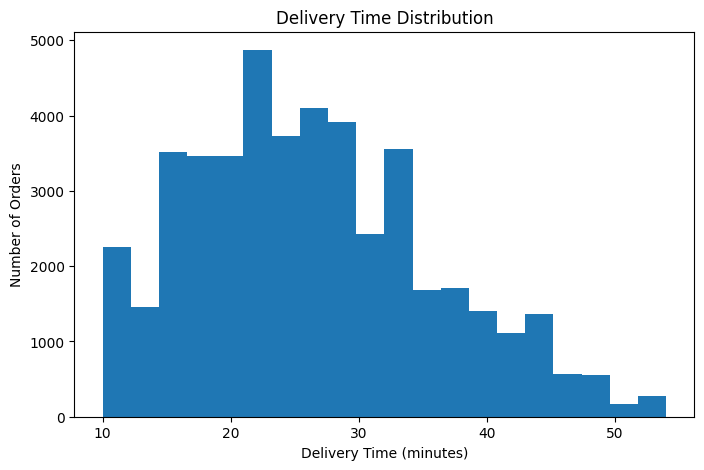

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train["Time_taken(min)"], bins=20)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Delivery Time Distribution")
plt.show()

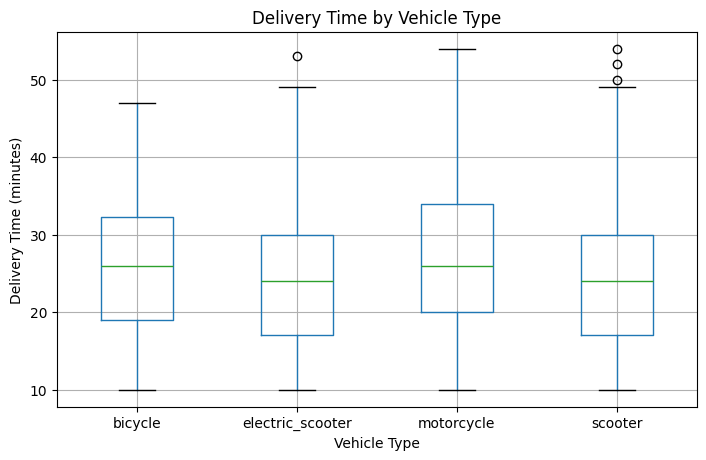

In [20]:
train.boxplot(column="Time_taken(min)", by="Type_of_vehicle", figsize=(8, 5))
plt.title("Delivery Time by Vehicle Type")
plt.suptitle("")
plt.xlabel("Vehicle Type")
plt.ylabel("Delivery Time (minutes)")
plt.show()

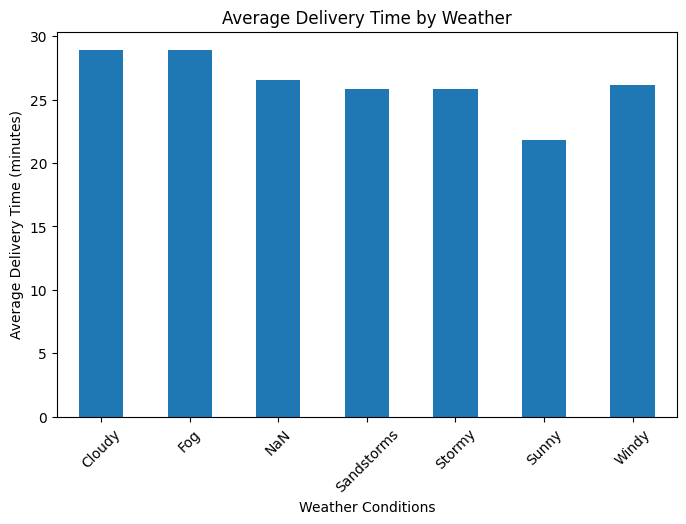

In [21]:
train.groupby("Weatherconditions")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather Conditions")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.show()

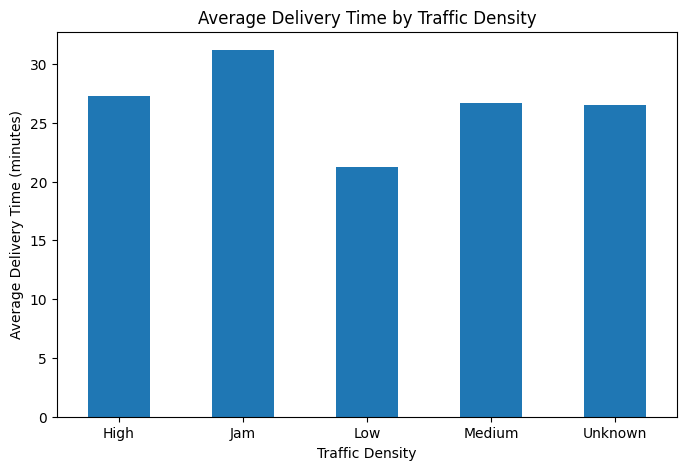

In [22]:
train.groupby("Road_traffic_density")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.show()

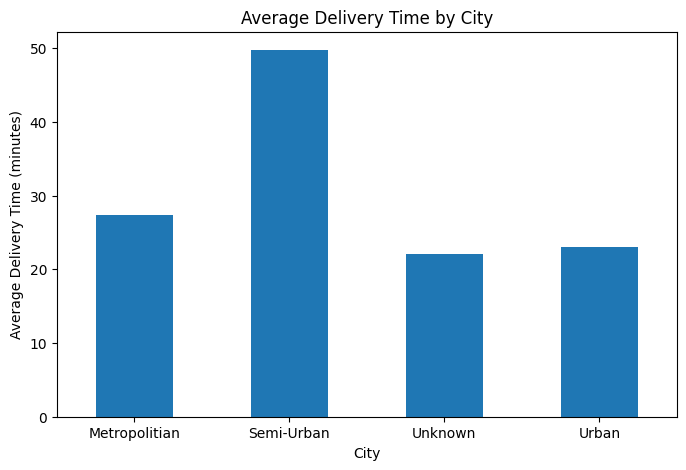

In [23]:
train.groupby("City")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.show()

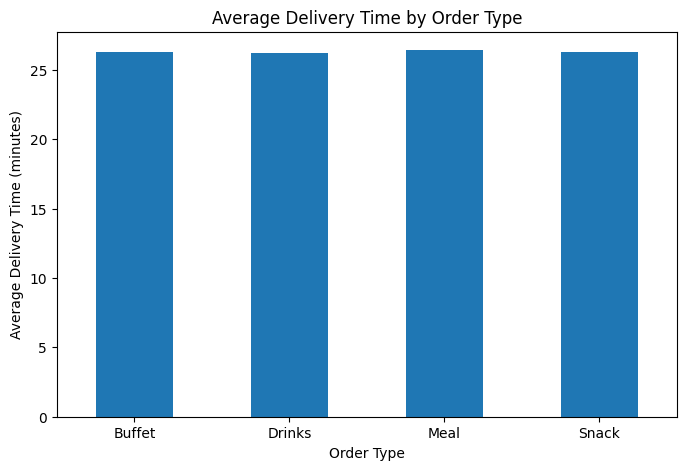

In [24]:
train.groupby("Type_of_order")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Order Type")
plt.xlabel("Order Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.show()

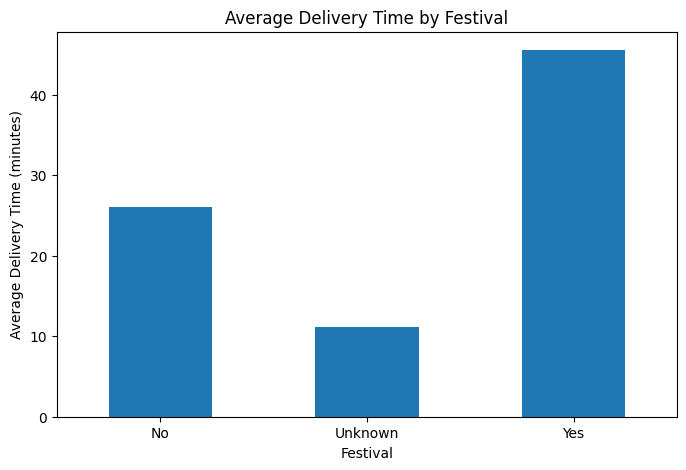

In [25]:
train.groupby("Festival")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Festival")
plt.xlabel("Festival")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.show()

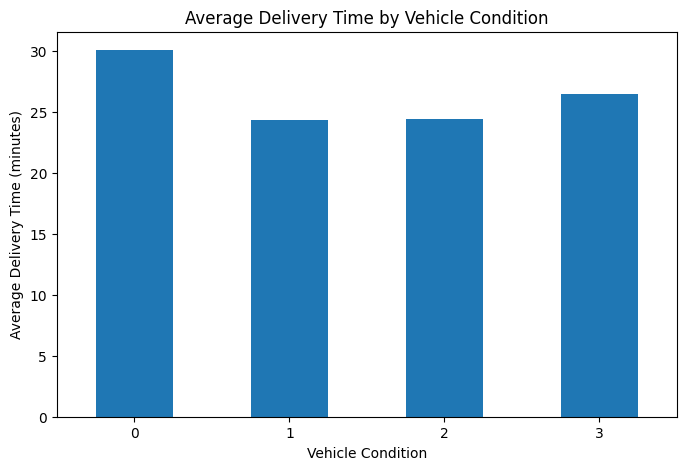

In [26]:
train.groupby("Vehicle_condition")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.show()

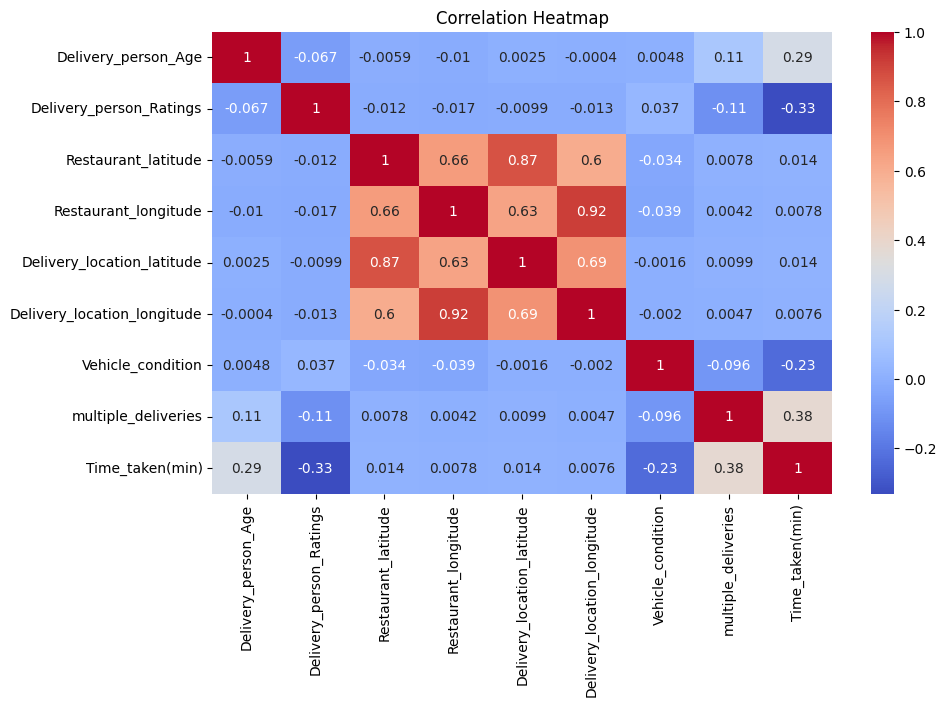

In [27]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(train.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [28]:
train.to_csv("cleaned_food_delivery_data.csv", index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [29]:
from google.colab import files
files.download("cleaned_food_delivery_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import os
os.makedirs("visualizations", exist_ok=True)

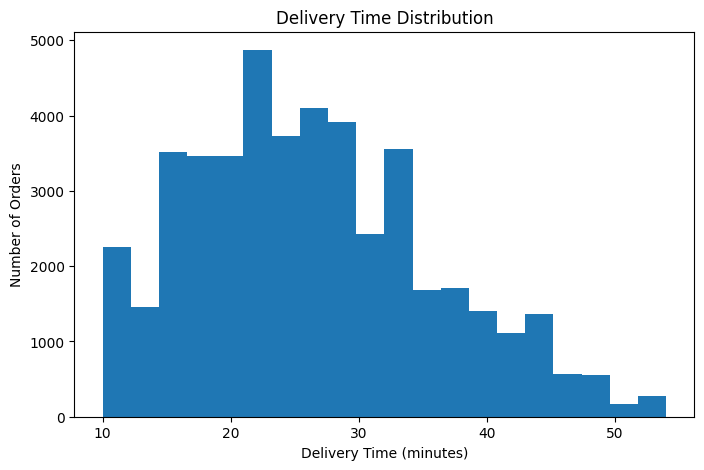

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(train["Time_taken(min)"], bins=20)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Delivery Time Distribution")
plt.savefig("visualizations/delivery_time_distribution.png", bbox_inches="tight")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [32]:
from google.colab import files
files.download("visualizations/delivery_time_distribution.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
from google.colab import files
files.download("visualizations/delivery_time_by_vehicle.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

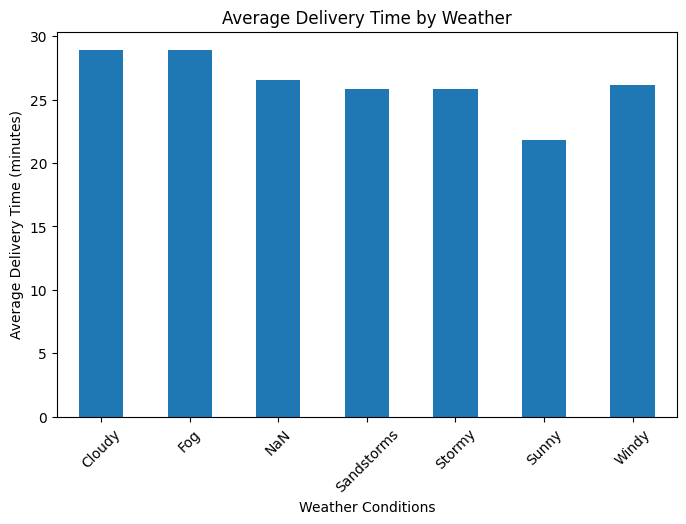

In [35]:
train.groupby("Weatherconditions")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather Conditions")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.savefig("visualizations/delivery_time_by_weather.png", bbox_inches="tight")
plt.show()

In [36]:
from google.colab import files
files.download("visualizations/delivery_time_by_weather.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

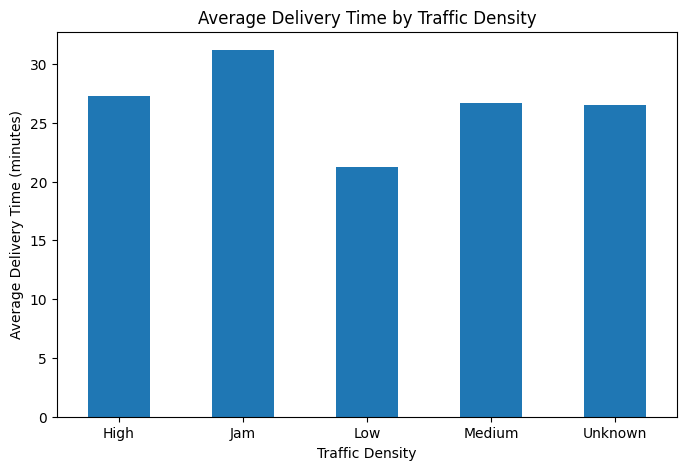

In [38]:
train.groupby("Road_traffic_density")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.savefig("visualizations/delivery_time_by_traffic.png", bbox_inches="tight")
plt.show()

In [39]:
from google.colab import files
files.download("visualizations/delivery_time_by_traffic.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

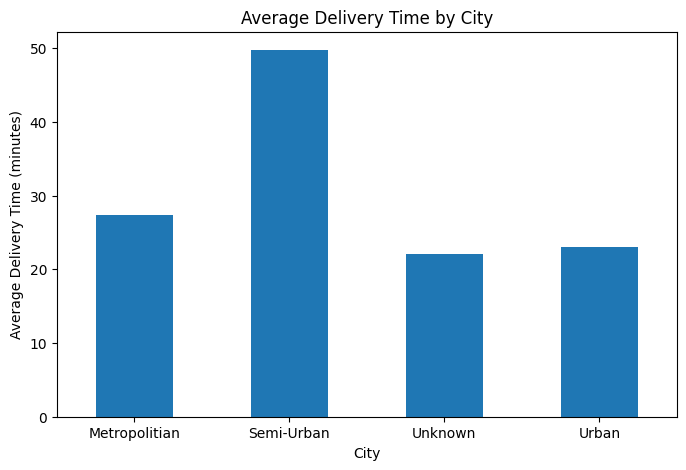

In [40]:
train.groupby("City")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.savefig("visualizations/delivery_time_by_city.png", bbox_inches="tight")
plt.show()

In [41]:
from google.colab import files
files.download("visualizations/delivery_time_by_city.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

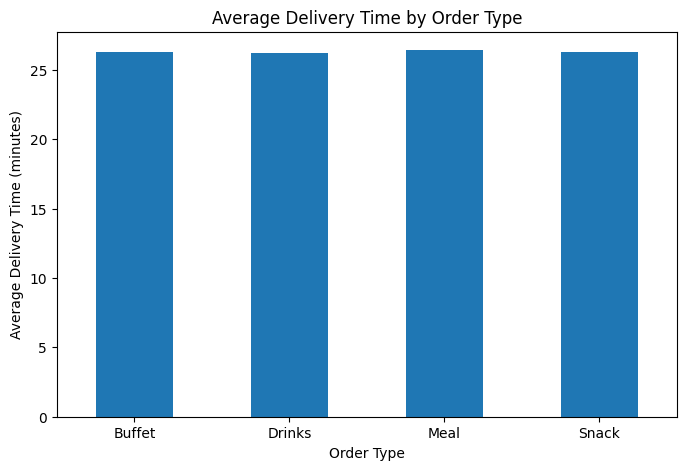

In [42]:
train.groupby("Type_of_order")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Order Type")
plt.xlabel("Order Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.savefig("visualizations/delivery_time_by_order_type.png", bbox_inches="tight")
plt.show()

In [43]:
from google.colab import files
files.download("visualizations/delivery_time_by_order_type.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

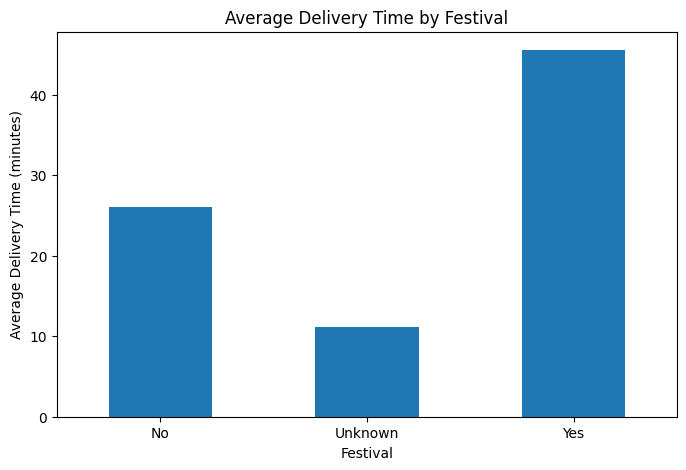

In [44]:
train.groupby("Festival")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Festival")
plt.xlabel("Festival")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.savefig("visualizations/delivery_time_by_festival.png", bbox_inches="tight")
plt.show()

In [45]:
from google.colab import files
files.download("visualizations/delivery_time_by_festival.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

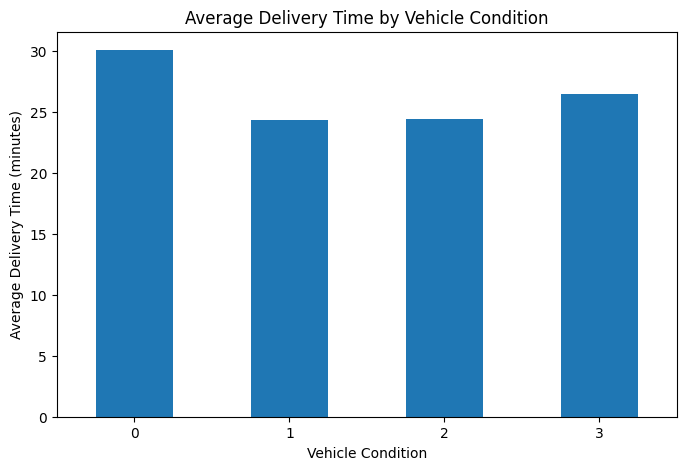

In [46]:
train.groupby("Vehicle_condition")["Time_taken(min)"].mean().plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.savefig("visualizations/delivery_time_by_vehicle_condition.png", bbox_inches="tight")
plt.show()

In [47]:
from google.colab import files
files.download("visualizations/delivery_time_by_vehicle_condition.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

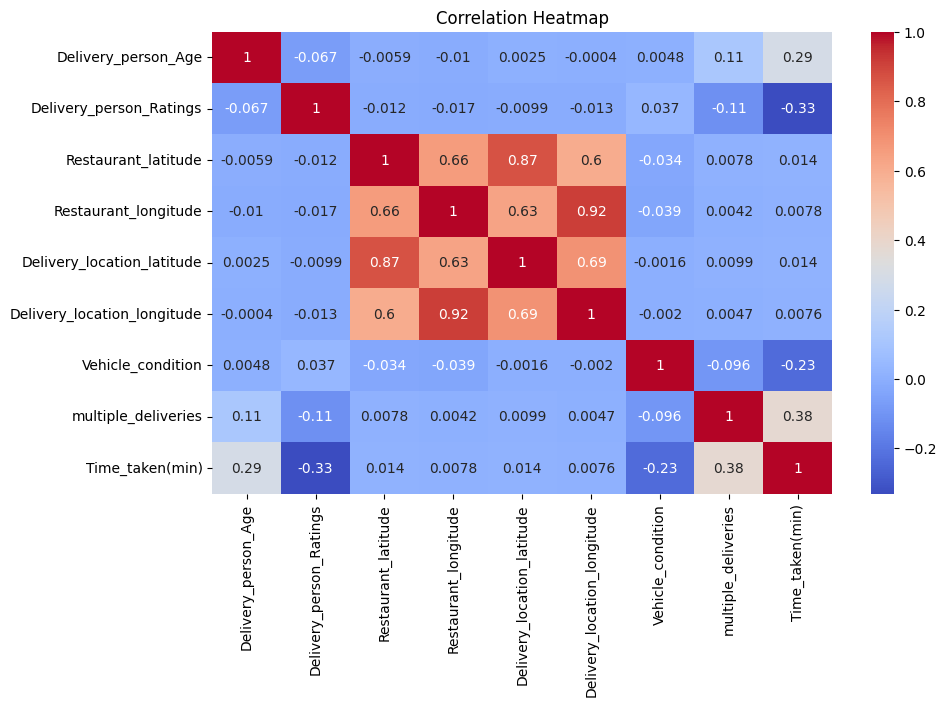

In [48]:
plt.figure(figsize=(10, 6))
sns.heatmap(train.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("visualizations/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [49]:
from google.colab import files
files.download("visualizations/correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>